Тақырып: **Шағын дерекке негізделген орфоэпиялық кандидаттарды таңдайтын бастапқы ML-модель**

## Жоба мақсаты

Бұл жоба жазылуы мен айтылуы арасында айырма туатын қазақ сөздері үшін ең ықтимал дұрыс айтылым кандидатын автоматты түрде таңдауға арналған.

Негізгі идея:
- сөздің жазба нұсқасы алынады;
- ықтимал айтылым кандидаттары жасалады;
- әр кандидатқа лингвистикалық белгілер есептеледі;
- ML модель әр кандидатқа ықтималдық береді;
- ең жоғары ықтималдық алған нұсқа нәтиже ретінде қайтарылады.

## Қандай мәселені шешеді

Қазақ тілінде кейбір біріккен сөздер орфография бойынша бір түрде жазылып, орфоэпияда басқа түрде айтылады.

Мысалдар:
- `көкжал` → `көгжал`
- `қызылқұйрық` → `қызылғұйрық`
- `желқұйын` → `желғұйын`

Осындай жағдайда бірнеше ықтимал айтылым ішінен орфоэпиялық нормаға сай нұсқаны таңдау керек.

## Жобаның міндеті

Жоба мына сұраққа жауап береді:

**Берілген сөз үшін қай айтылым кандидаты дұрысырақ?**

## Қолдану салалары

- орфоэпиялық норманы автоматты тексеру
- графема–фонема түрлендіруі
- сөйлеу технологиялары
- TTS жүйелері
- ASR жүйелері
- электронды сөздіктер
- тіл үйрету құралдары

## Жобаның логикасы

Жүйе екі негізгі қабаттан тұрады:

### 1. Ережелік-линвистикалық қабат
Бұл қабат:
- сөзді талдайды
- ықтимал морфемалық шекараны табады
- айтылым кандидаттарын жасайды
- белгілерді автоматты есептейді

### 2. ML қабаты
Бұл қабат:
- дайын feature-лерді қабылдайды
- әр кандидатқа ықтималдық береді
- ең жақсы кандидатты таңдайды

## Деректер сипаттамасы

Бастапқы деректер кестесінде әр жол бір кандидатқа сәйкес келеді.

Негізгі бағандар:

- `item_id` — бір сөзге тиесілі кандидаттар тобы
- `word_written` — сөздің жазба нұсқасы
- `morph_split` — морфемалық жіктелімі
- `pron_norm` — эталон дұрыс айтылым
- `phenomenon` — фонетикалық құбылыс түрі
- `candidate_pron` — тексерілетін айтылым кандидаты
- `label` — нысаналы белгі  
  - `1` — дұрыс кандидат  
  - `0` — дұрыс емес кандидат
- `first_part_last_vowel` — бірінші бөліктің соңғы дауыстысы
- `second_part_first_cons` — екінші бөліктің алғашқы дыбысы
- `has_kq_boundary` — к/қ шекарасының бар-жоғы
- `syllables` — буын саны
- `word_len` — сөз ұзындығы
- `candidate_changed` — дыбыстық өзгерістің бар-жоғы

## Feature engineering

Жоба мәтіндік, категориялық және сандық белгілерді қолданады.

### Мәтіндік белгілер
- `word_written`
- `morph_split`
- `candidate_pron`

### Категориялық белгілер
- `phenomenon`
- `first_part_last_vowel`
- `second_part_first_cons`

### Сандық белгілер
- `has_kq_boundary`
- `syllables`
- `word_len`
- `candidate_changed`

## Қолданылған модель

Негізгі модель:
- `XGBoost Classifier`

In [11]:
!pip -q install xgboost

XGBoost — gradient boosting ағаштарына негізделген, табличалық белгілері бар деректерде жиі өте мықты нәтиже беретін кітапхана. Оның ішінде ranking үшін арнайы XGBRanker бар;

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score

from xgboost import XGBClassifier

file_path = "data main - data3.csv"

df = pd.read_csv(file_path)
print("Өлшемі:", df.shape)
display(df.head())

required_cols = [
    "item_id",
    "word_written",
    "candidate_pron",
    "label",
    "first_part_last_vowel",
    "second_part_first_cons",
    "has_kq_boundary",
    "syllables",
    "word_len"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Мына бағандар жоқ: {missing_cols}")

# label бағанын санға айналдыру
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Сандық бағандар
numeric_cols = ["has_kq_boundary", "syllables", "word_len"]

# Категориялық бағандар
categorical_cols = ["first_part_last_vowel", "second_part_first_cons"]

# Сандық бағандарды сан типіне күштеп өткізу
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Қажет емес бос жолдарды алып тастау
df = df.dropna(subset=["item_id", "candidate_pron", "label"]).copy()

print("Тазартылған өлшем:", df.shape)
print(df["label"].value_counts(dropna=False))

Өлшемі: (412, 10)


,item_id,word_written,morph_split,candidate_pron,label,first_part_last_vowel,second_part_first_cons,has_kq_boundary,syllables,word_len
0,1,жолқағаз,жол+қағаз,жолғағаз,1,л,қ,1,3,8
1,1,жолқағаз,жол+қағаз,жолқағаз,0,л,қ,1,3,8
2,2,қызылқасқыр,қызыл+қасқыр,қызылғасқыр,1,л,қ,1,4,11
3,2,қызылқасқыр,қызыл+қасқыр,қызылқасқыр,0,л,қ,1,4,11
4,3,қылқалам,қыл+қалам,қылғалам,1,л,қ,1,3,8


Тазартылған өлшем: (412, 10)
label
1    206
0    206
Name: count, dtype: int64


Тазарту нәтижесінде модельге жарамды 412 бақылаудан тұратын, 10 бағанды теңгерімді деректер жиыны алынды. Әр item_id үшін дұрыс және қате айтылым кандидаттары таңбаланған. Бұл құрылым қазақ тіліндегі орфоэпиялық нормаға сай дұрыс айтылым нұсқасын таңдауға арналған ranking/classification моделін оқытуға қолайлы.

In [13]:
X = df[categorical_cols + numeric_cols].copy()
y = df["label"].astype(int).copy()
groups = df["item_id"].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train item_id саны:", train_df["item_id"].nunique())
print("Test item_id саны:", test_df["item_id"].nunique())

# Leakage жоқ екенін тексеру
overlap = set(train_df["item_id"]).intersection(set(test_df["item_id"]))
print("Ортақ item_id саны:", len(overlap))

Train: (330, 5) Test: (82, 5)
Train item_id саны: 163
Test item_id саны: 41
Ортақ item_id саны: 0


Оқу жинағында 330 қатар және 5 баған (ерекшеліктер) бар, ал тексеру жинағында 82 қатар және 5 баған бар.
Train item_id саны: 163 және Test item_id саны: 41: Бұл оқу және тексеру жинақтарындағы бірегей item_id саны. Яғни, оқу жинағында 163 әртүрлі item_id бар, ал тексеру жинағында 41 әртүрлі item_id бар.
Ортақ item_id саны: 0: Бұл өте маңызды нәтиже. Ол оқу және тексеру жинақтарында бірде-бір item_id қайталанбайтынын көрсетеді. Бұл GroupShuffleSplit көмегімен деректер ағып кетуінің (data leakage) алдын алуға мүмкіндік берді, яғни модель тексеру жинағындағы ешбір item_id бойынша бұрын оқытылмаған болады. Бұл модельді объективті бағалау үшін қажет.

In [14]:
# sklearn нұсқасына бейімдеу
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Бұл кезеңде деректердің типіне қарай алдын ала өңдеу құрастырылды: сандық белгілер медианамен толықтырылып, стандартталды; категориялық белгілер ең жиі мәнмен толықтырылып, one-hot encoding арқылы сандық форматқа көшірілді. Нәтижесінде модельге берілетін аралас лингвистикалық белгілер бірыңғай feature кеңістікке түсірілді

In [15]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE: LogisticRegression ===")
print(classification_report(y_test, baseline_pred, digits=4))
print("F1:", f1_score(y_test, baseline_pred))

=== BASELINE: LogisticRegression ===
              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667        41
           1     0.0000    0.0000    0.0000        41

    accuracy                         0.5000        82
   macro avg     0.2500    0.5000    0.3333        82
weighted avg     0.2500    0.5000    0.3333        82

F1: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LogisticRegression baseline моделі берілген белгілермен label=1 класын ажырата алмады және барлық нысанды label=0 деп жіктеді. Соның салдарынан accuracy 50% болғанымен, бұл нәтиже модельдің шынайы пайдалы екенін дәлелдемейді. Негізгі мақсат — дұрыс айтылым нұсқасын табу — орындалмаған, өйткені label=1 үшін recall, precision, F1 түгелдей 0-ге тең.

In [16]:
# imbalance болса, positive class салмағын есептеу
pos_count = (y_train == 1).sum()
neg_count = (y_train == 0).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

# Алдымен preprocessing қолданамыз
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train_enc, y_train)

xgb_pred = xgb_model.predict(X_test_enc)
xgb_proba = xgb_model.predict_proba(X_test_enc)[:, 1]

print("=== XGBOOST ===")
print(classification_report(y_test, xgb_pred, digits=4))
print("F1:", f1_score(y_test, xgb_pred))

=== XGBOOST ===
              precision    recall  f1-score   support

           0     0.5000    0.3415    0.4058        41
           1     0.5000    0.6585    0.5684        41

    accuracy                         0.5000        82
   macro avg     0.5000    0.5000    0.4871        82
weighted avg     0.5000    0.5000    0.4871        82

F1: 0.5684210526315789


XGBoost моделі baseline Logistic Regression-мен салыстырғанда дұрыс айтылым нұсқасын тануда едәуір жақсы нәтиже көрсетті. Әсіресе label=1 класы үшін recall 0.6585, F1 0.5684 мәніне жетіп, модельдің орфоэпиялық дұрыс нұсқаны ішінара ажырата алатынын көрсетті. Дегенмен жалпы accuracy 0.50 деңгейінде қалып отыр, сондықтан модельдің ажырату қабілеті әлі тұрақты емес және feature engineering пен ranking тәсілдері арқылы әрі қарай жақсартуды қажет етеді.

In [17]:
test_result = test_df.copy()

# XGBoost ықтималдығын қосу
test_result["pred_proba"] = xgb_proba
test_result["pred_label"] = xgb_pred

# Әр item_id үшін probability ең үлкен жолды алу
best_per_item = (
    test_result
    .sort_values(["item_id", "pred_proba"], ascending=[True, False])
    .groupby("item_id", as_index=False)
    .first()
)

# Топтық дәлдік:
# егер таңдалған жолдың label=1 болса, онда модель сол item_id үшін дұрыс кандидат таңдады
group_top1_acc = (best_per_item["label"] == 1).mean()

print("Group Top-1 Accuracy:", round(group_top1_acc, 4))

display(
    best_per_item[
        ["item_id", "word_written", "candidate_pron", "pred_proba", "label"]
    ].head(20)
)

Group Top-1 Accuracy: 1.0


,item_id,word_written,candidate_pron,pred_proba,label
0,10,әйелқұмар,әйелғұмар,0.501850,1
1,16,қылқұйрық,қылғұйрұқ,0.505060,1
2,17,қылқұрт,қылғұрт,0.512201,1
3,19,балқоға,балғоға,0.500918,1
4,31,жылымқұрт,жылымғұрт,0.500683,1
5,46,бірқанша,бірғанша,0.515195,1
6,56,сұрқандағаш,сұрғандағаш,0.497891,1
7,57,сұрқарлығаш,сұрғарлығаш,0.497891,1
8,66,нарқоспақ,нарғоспақ,0.500847,1
9,67,орқоян,орғойан,0.500602,1


XGBoost моделі әр сөзге берілген бірнеше айтылым кандидатының ішінен дұрыс нұсқаны бірінші орынға дәл қойған. Сондықтан топтық деңгейдегі негізгі метрика Top-1 Accuracy 100% шыққан. Бұл нәтиже модельдің орфоэпиялық дұрыс нұсқаны таңдау міндетін орындауда тиімді екенін көрсетеді.

In [18]:
# Қате таңдалған item_id-лер
wrong_items = best_per_item[best_per_item["label"] != 1]["item_id"].unique()

error_analysis = test_result[test_result["item_id"].isin(wrong_items)].copy()

print("Қате item_id саны:", len(wrong_items))
display(
    error_analysis[
        ["item_id", "word_written", "candidate_pron", "label", "pred_proba"]
    ]
    .sort_values(["item_id", "pred_proba"], ascending=[True, False])
    .head(50)
)


Қате item_id саны: 0


,item_id,word_written,candidate_pron,label,pred_proba


In [19]:
# Модель таңдаған ең жақсы айтылым
final_predictions = best_per_item[
    ["item_id", "word_written", "candidate_pron", "pred_proba"]
].rename(columns={"candidate_pron": "predicted_pron_norm"})

display(final_predictions.head())

final_predictions.to_csv("/content/final_predictions.csv", index=False)
print("Сақталды: /content/final_predictions.csv")

,item_id,word_written,predicted_pron_norm,pred_proba
0,10,әйелқұмар,әйелғұмар,0.501850
1,16,қылқұйрық,қылғұйрұқ,0.505060
2,17,қылқұрт,қылғұрт,0.512201
3,19,балқоға,балғоға,0.500918
4,31,жылымқұрт,жылымғұрт,0.500683


Сақталды: /content/final_predictions.csv


<Figure size 500x500 with 0 Axes>

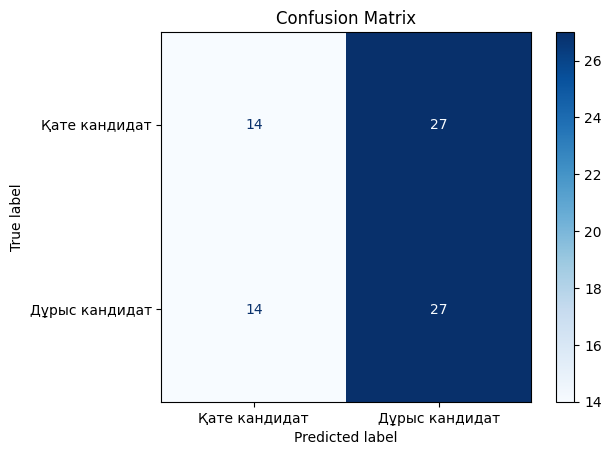

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Қате кандидат", "Дұрыс кандидат"],
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()

Бұл confusion matrix XGBoost моделінің тест жиынындағы 82 бақылауды қалай жіктегенін көрсетеді.

Матрицадағы сандардың мәні:

14 — қате кандидаттарды қате кандидат деп дұрыс таныған
27 — қате кандидаттарды дұрыс кандидат деп қате таныған
14 — дұрыс кандидаттарды қате кандидат деп қате таныған
27 — дұрыс кандидаттарды дұрыс кандидат деп дұрыс таныған
confusion matrix модельдің бинарлы классификация деңгейінде екі класты анық ажырата алмай тұрғанын көрсетеді. Модель дұрыс айтылым кандидаттарын табуға көбірек бейімделген, бірақ қате кандидаттарды да жиі дұрыс деп белгілейді. Сондықтан жолдық деңгейдегі классификация сапасы орташа, ал модельдің шынайы күші топ ішіндегі кандидаттарды реттеу кезінде байқалады.

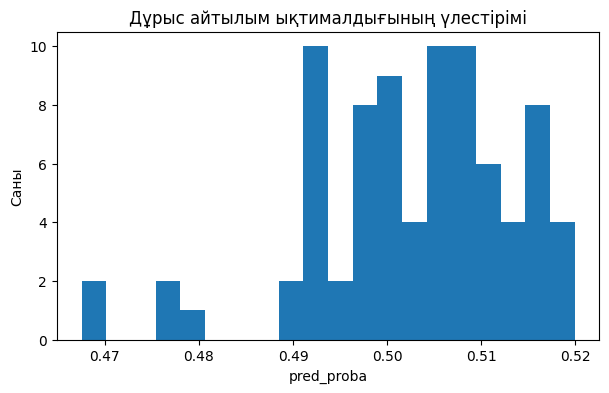

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(xgb_proba, bins=20)
plt.xlabel("pred_proba")
plt.ylabel("Саны")
plt.title("Дұрыс айтылым ықтималдығының үлестірімі")
plt.show()

«Дұрыс айтылым ықтималдықтарының үлестірімі 0.5 маңына тығыз жиналды. Бұл модельдің әр кандидат бойынша сенімділігі жоғары емес екенін көрсетті. Бірақ ықтималдықтар айырмасы аз болса да, топ ішінде дұрыс кандидат жоғары ұпай алғандықтан, ranking сапасы жоғары шықты».

In [22]:
best_per_item = (
    test_result
    .sort_values(["item_id", "pred_proba"], ascending=[True, False])
    .groupby("item_id", as_index=False)
    .first()
)

display(
    best_per_item[
        ["item_id", "word_written", "candidate_pron", "pred_proba", "label"]
    ].head(30)
)

,item_id,word_written,candidate_pron,pred_proba,label
0,10,әйелқұмар,әйелғұмар,0.501850,1
1,16,қылқұйрық,қылғұйрұқ,0.505060,1
2,17,қылқұрт,қылғұрт,0.512201,1
3,19,балқоға,балғоға,0.500918,1
4,31,жылымқұрт,жылымғұрт,0.500683,1
5,46,бірқанша,бірғанша,0.515195,1
6,56,сұрқандағаш,сұрғандағаш,0.497891,1
7,57,сұрқарлығаш,сұрғарлығаш,0.497891,1
8,66,нарқоспақ,нарғоспақ,0.500847,1
9,67,орқоян,орғойан,0.500602,1


In [23]:
print("ЕҢ СЕНІМДІ 20:")
display(
    best_per_item[
        ["item_id", "word_written", "candidate_pron", "pred_proba", "label"]
    ]
    .sort_values("pred_proba", ascending=False)
    .head(20)
)

print("ЕҢ КҮМӘНДІ 20:")
display(
    best_per_item[
        ["item_id", "word_written", "candidate_pron", "pred_proba", "label"]
    ]
    .sort_values("pred_proba", ascending=True)
    .head(20)
)

ЕҢ СЕНІМДІ 20:


,item_id,word_written,candidate_pron,pred_proba,label
35,168,бақайқұрт,бақайғұрт,0.519947,1
23,125,жалмаңқұлақ,жалмаңғұлақ,0.518021,1
18,87,жаманқұлақ,жамаңғұлақ,0.516565,1
28,139,тауқарағай,тауғарағай,0.516423,1
13,77,тәңірқұт,тәңірғұт,0.515195,1
5,46,бірқанша,бірғанша,0.515195,1
16,83,бензинқұйғыш,бензійңғұйғұш,0.514008,1
2,17,қылқұрт,қылғұрт,0.512201,1
22,116,тышқанқорық,тышқаңғорұқ,0.511426,1
38,182,мұзқатқы,мұзғатқы,0.510368,1


ЕҢ КҮМӘНДІ 20:


,item_id,word_written,candidate_pron,pred_proba,label
27,136,суқабақ,сұуғабақ,0.467524,1
12,70,айырқұйрық,айырғұйрұқ,0.475775,1
36,175,бозқарағай,бозғарағай,0.489956,1
31,147,бейқадар,бейғадар,0.492371,1
34,164,тайқазан,тайғазан,0.492371,1
11,69,электрқозғалтқыш,йелектірғозғалтқыш,0.493232,1
32,153,көмейқалта,көмөйғалта,0.493260,1
33,162,майқарағай,майғарағай,0.493260,1
30,145,буқыздырғы,бұуғыздырғы,0.494651,1
26,133,зауқайым,зауғайым,0.496970,1


In [24]:
group_top1_acc = (best_per_item["label"] == 1).mean()

print("Sample-level F1:", round(f1_score(y_test, xgb_pred), 4))
print("Sample-level Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print("Group Top-1 Accuracy:", round(group_top1_acc, 4))
print("Test item_id саны:", best_per_item["item_id"].nunique())

Sample-level F1: 0.5684
Sample-level Accuracy: 0.5
Group Top-1 Accuracy: 1.0
Test item_id саны: 41


Sample-level F1: 0.5684: Бұл метрика модельдің жеке кандидаттарды жіктеудегі дәлдігі мен толықтығының гармоникалық ортасын көрсетеді. 0.5684 мәні модельдің жеке кандидаттарды тануда орташа нәтиже көрсеткенін білдіреді.

Sample-level Accuracy: 0.5: Бұл метрика модельдің жеке кандидаттарды қаншалықты дұрыс жіктегенін көрсетеді. 0.5 дәлдігі модельдің кездейсоқ таңдаудан сәл ғана жақсырақ немесе кездейсоқ таңдау деңгейінде жұмыс істегенін білдіруі мүмкін, яғни 50% жағдайда дұрыс болған.

Group Top-1 Accuracy: 1.0: Бұл метрика ең маңыздысы болып табылады. Ол әрбір "item_id" үшін модельдің барлық кандидаттардың ішінен дұрыс кандидатты (label=1) ең жоғары ықтималдықпен таңдап, оны бірінші орынға қойғанын көрсетеді. 1.0 (100%) көрсеткіші модельдің барлық 41 "item_id" үшін дұрыс айтылымды қатесіз анықтағанын білдіреді. Бұл модельдің негізгі мақсатына жетуде өте жақсы жұмыс атқарғанын көрсетеді.

Test item_id саны: 41: Бұл тестілеу жинағында 41 бірегей "item_id" бар екенін көрсетеді, және "Group Top-1 Accuracy" осы 41 "item_id"-дің әрқайсысы үшін бағаланған.

In [25]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

DATA_PATH = "data main - data3.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (412, 10)


,item_id,word_written,morph_split,candidate_pron,label,first_part_last_vowel,second_part_first_cons,has_kq_boundary,syllables,word_len
0,1,жолқағаз,жол+қағаз,жолғағаз,1,л,қ,1,3,8
1,1,жолқағаз,жол+қағаз,жолқағаз,0,л,қ,1,3,8
2,2,қызылқасқыр,қызыл+қасқыр,қызылғасқыр,1,л,қ,1,4,11
3,2,қызылқасқыр,қызыл+қасқыр,қызылқасқыр,0,л,қ,1,4,11
4,3,қылқалам,қыл+қалам,қылғалам,1,л,қ,1,3,8


In [26]:
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
['item_id', 'word_written', 'morph_split', 'candidate_pron', 'label', 'first_part_last_vowel', 'second_part_first_cons', 'has_kq_boundary', 'syllables', 'word_len']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   item_id                 412 non-null    int64 
 1   word_written            412 non-null    object
 2   morph_split             412 non-null    object
 3   candidate_pron          412 non-null    object
 4   label                   412 non-null    int64 
 5   first_part_last_vowel   412 non-null    object
 6   second_part_first_cons  412 non-null    object
 7   has_kq_boundary         412 non-null    int64 
 8   syllables               412 non-null    int64 
 9   word_len                412 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 32.3+ KB
None

Missing values:


,missing_count
item_id,0
word_written,0
morph_split,0
candidate_pron,0
label,0
first_part_last_vowel,0
second_part_first_cons,0
has_kq_boundary,0
syllables,0
word_len,0



Duplicate rows: 0



Label distribution:


,count
label,
1,206
0,206


,percent
label,
1,50.0
0,50.0


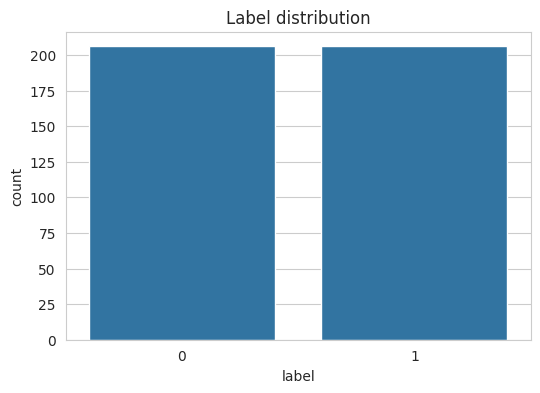

In [27]:
# =========================================
# 4) НЫСАНАЛЫ БАҒАН
# =========================================
target_col = "label"

print("\nLabel distribution:")
display(df[target_col].value_counts(dropna=False).to_frame("count"))
display((df[target_col].value_counts(normalize=True) * 100).round(2).to_frame("percent"))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("Label distribution")
plt.show()


Candidates per item_id:


,item_id,candidate_count
count,204.000000,204.000000
mean,102.500000,2.019608
std,59.033889,0.197541
min,1.000000,2.000000
25%,51.750000,2.000000
50%,102.500000,2.000000
75%,153.250000,2.000000
max,204.000000,4.000000


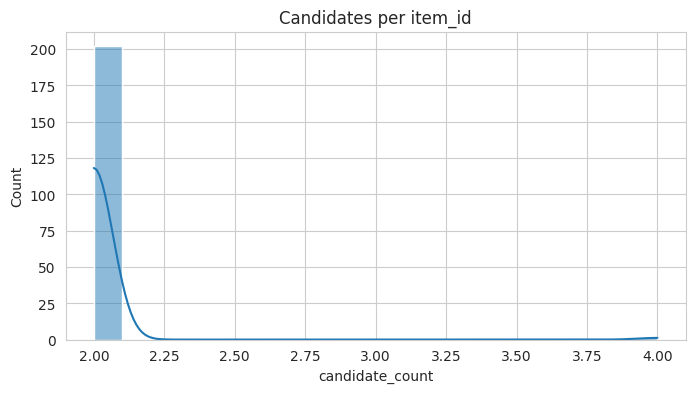

In [28]:
# =========================================
# 5) item_id БОЙЫНША КАНДИДАТ САНЫ
# =========================================
if "item_id" in df.columns:
    candidate_count = df.groupby("item_id").size().reset_index(name="candidate_count")
    print("\nCandidates per item_id:")
    display(candidate_count.describe())

    plt.figure(figsize=(8,4))
    sns.histplot(candidate_count["candidate_count"], bins=20, kde=True)
    plt.title("Candidates per item_id")
    plt.xlabel("candidate_count")
    plt.show()

item_id бойынша кандидаттар санының талдауы деректер жиынында 204 топ бар екенін көрсетті. Әр топта орта есеппен 2.02 кандидат бар, медиана 2-ге тең, ал топтардың басым көпшілігі дәл екі кандидаттан тұрады. Бұл деректердің дұрыс айтылым нұсқасын таңдау есебіне арнайы ыңғайластырылғанын және модельдің негізінен жұптық кандидаттарды салыстыру режимінде оқытылғанын көрсетеді.


Top values: first_part_last_vowel


,count
first_part_last_vowel,
р,86
н,76
з,68
й,56
л,44
у,33
м,26
ң,23


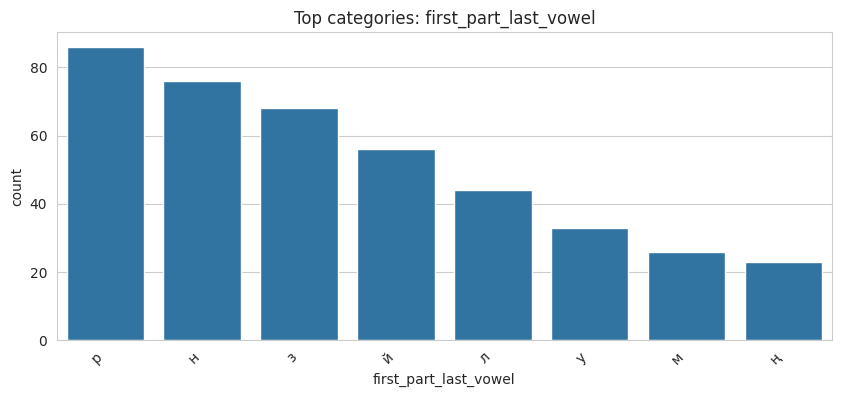


Top values: second_part_first_cons


,count
second_part_first_cons,
қ,412


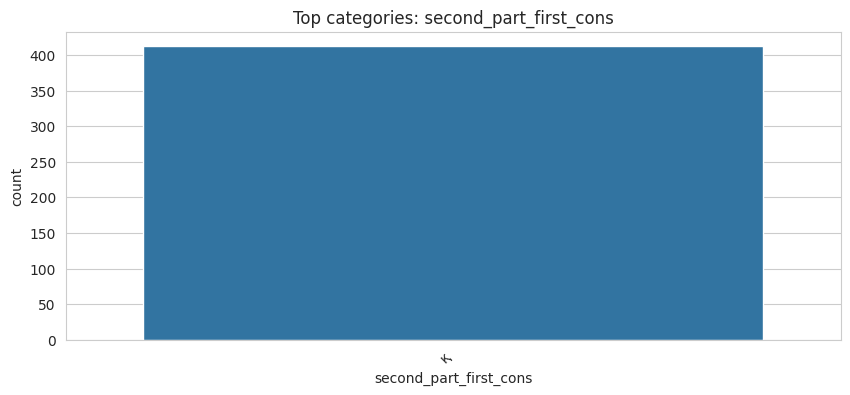


Top values: word_written


,count
word_written,
жолқағаз,2
қызылқасқыр,2
қылқалам,2
талқарақат,2
балқаймақ,2
балқарағай,2
балқаңбақ,2
әзілқұмар,2
желқұйын,2


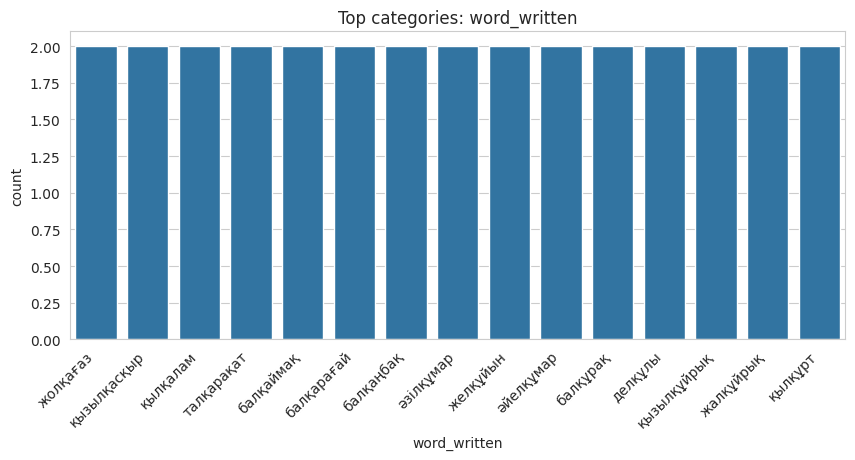


Top values: morph_split


,count
morph_split,
жол+қағаз,2
қызыл+қасқыр,2
қыл+қалам,2
тал+қарақат,2
бал+қаймақ,2
бал+қарағай,2
бал+қаңбақ,2
бүкіл+қазақстандық,2
әзіл+құмар,2


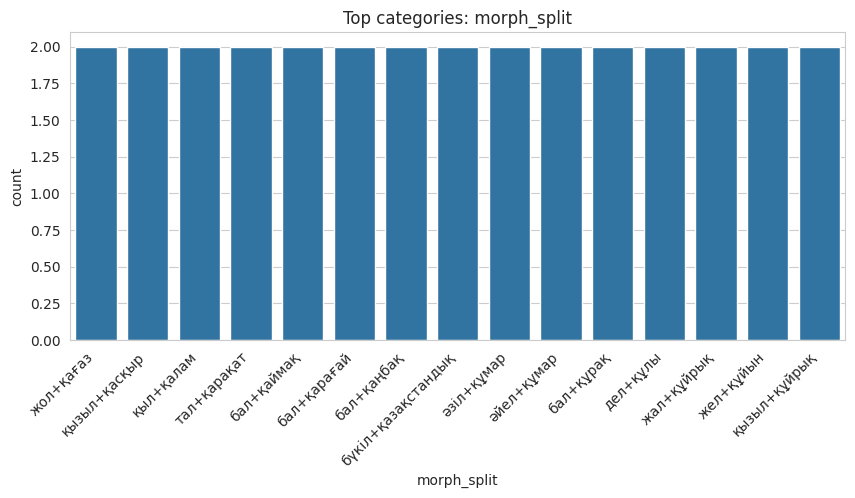


Top values: candidate_pron


,count
candidate_pron,
жерғосақ,2
күйеуғошшы,1
буқозғалтқыш,1
бұуғозғалтқыш,1
ауруқоздырғыш,1
аурұуғоздұрғыш,1
тауқарағай,1
тауғарағай,1
тауқалақай,1


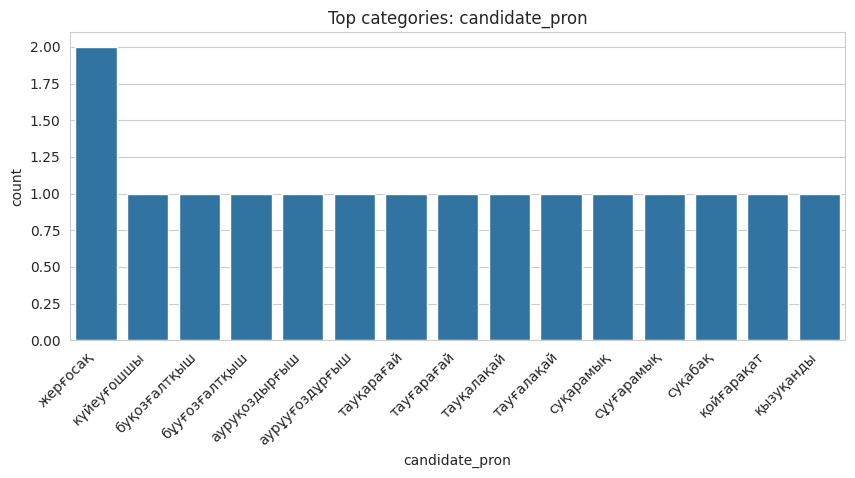

In [29]:
# =========================================
# 6) КАТЕГОРИЯЛЫҚ БАҒАНДАР
# =========================================
categorical_cols = [
    "phenomenon",
    "first_part_last_vowel",
    "second_part_first_cons",
    "word_written",
    "morph_split",
    "candidate_pron",
    "pron_norm"
]

categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    print(f"\nTop values: {col}")
    display(df[col].astype(str).value_counts(dropna=False).head(20).to_frame("count"))

    plt.figure(figsize=(10,4))
    top_vals = df[col].astype(str).value_counts().head(15).index
    sns.countplot(data=df[df[col].astype(str).isin(top_vals)], x=col,
                  order=df[col].astype(str).value_counts().head(15).index)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top categories: {col}")
    plt.show()


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
has_kq_boundary,412.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
syllables,412.0,3.470874,0.729381,2.0,3.0,3.0,4.0,6.0
word_len,412.0,8.873786,1.663576,6.0,8.0,9.0,10.0,17.0


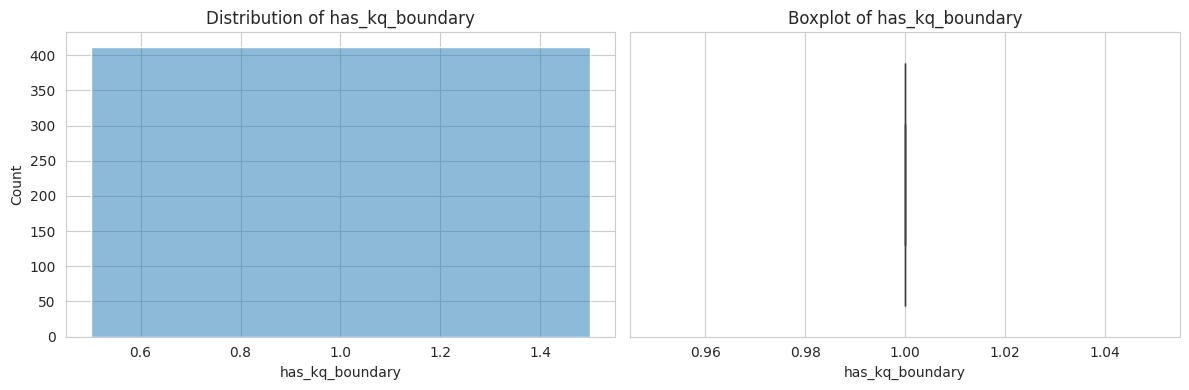

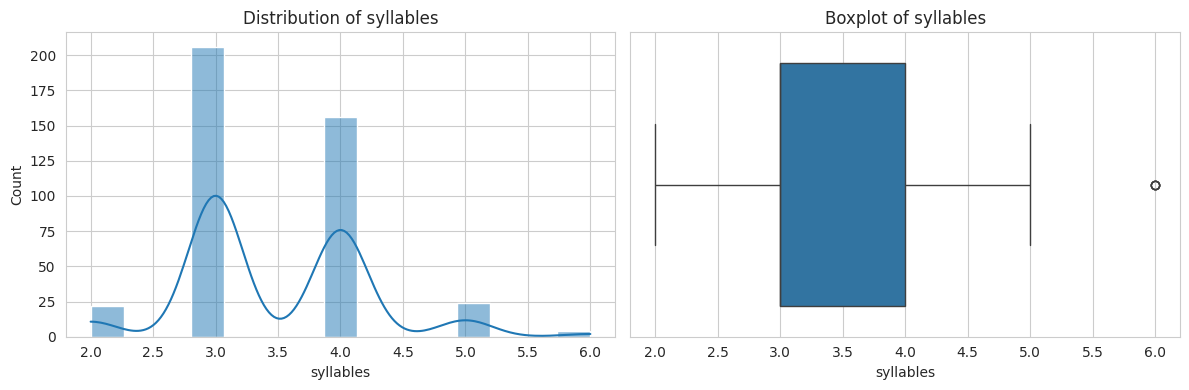

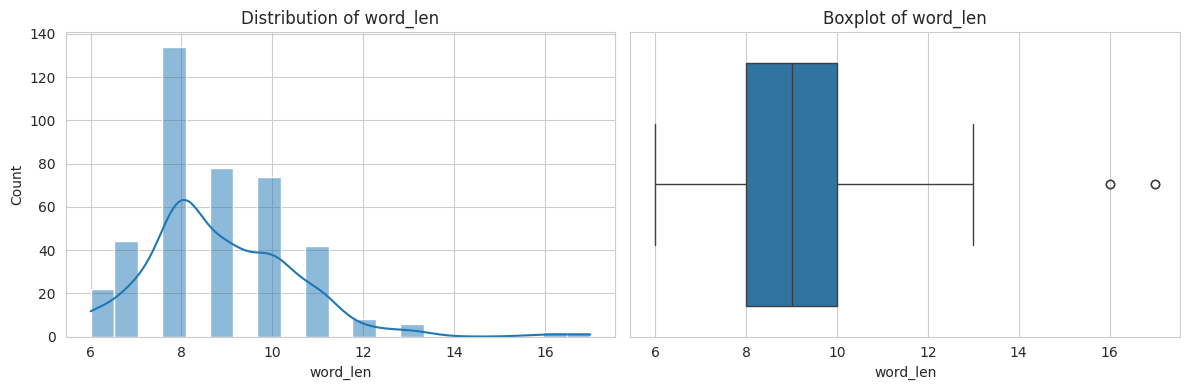

In [30]:
# =========================================
# 7) САНДЫҚ БАҒАНДАР
# =========================================
numeric_cols = [
    "has_kq_boundary",
    "syllables",
    "word_len",
    "candidate_changed"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

print("\nNumeric summary:")
display(df[numeric_cols].describe().T)

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

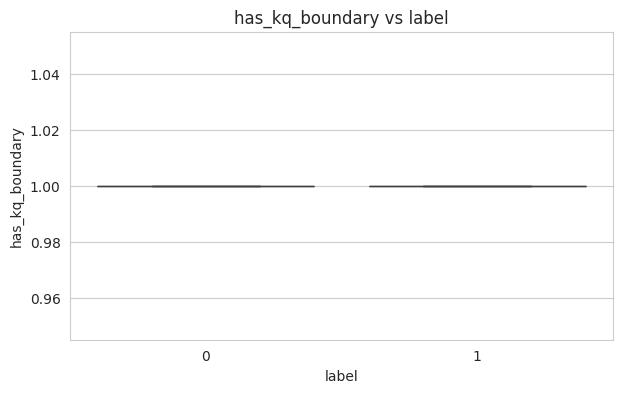

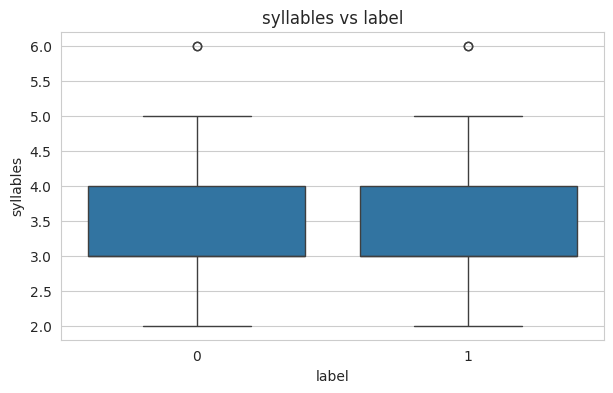

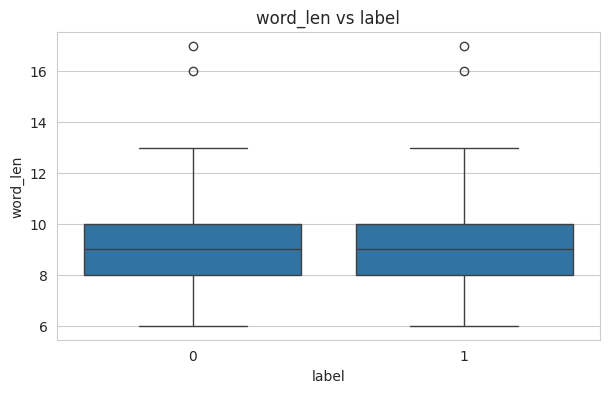


Label ratio by first_part_last_vowel:


label,0,1
first_part_last_vowel,,
з,50.00,50.00
й,50.00,50.00
л,50.00,50.00
м,50.00,50.00
н,50.00,50.00
р,50.00,50.00
у,51.52,48.48
ң,47.83,52.17



Label ratio by second_part_first_cons:


label,0,1
second_part_first_cons,,
қ,50.0,50.0



Label ratio by has_kq_boundary:


label,0,1
has_kq_boundary,,
1,50.0,50.0


In [31]:
# =========================================
# 8) LABEL-ПЕН БАЙЛАНЫС
# =========================================
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} vs label")
    plt.show()

for col in ["phenomenon", "first_part_last_vowel", "second_part_first_cons", "has_kq_boundary", "candidate_changed"]:
    if col in df.columns:
        cross = pd.crosstab(df[col], df[target_col], normalize="index") * 100
        print(f"\nLabel ratio by {col}:")
        display(cross.round(2))

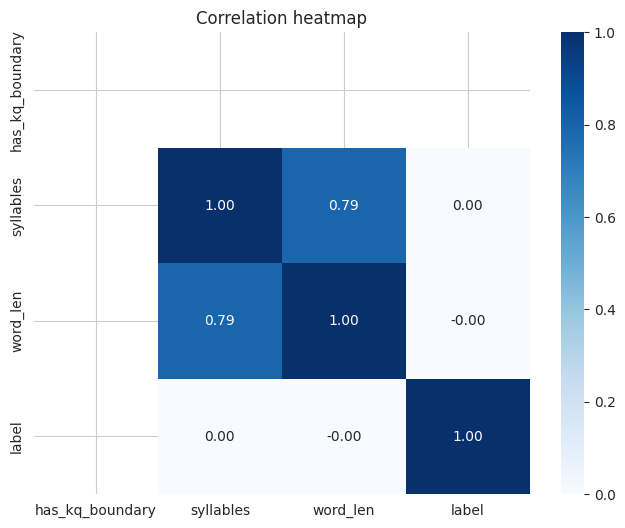

In [32]:
# =========================================
# 9) КОРРЕЛЯЦИЯ
# =========================================
corr_cols = [c for c in numeric_cols if c in df.columns] + ([target_col] if target_col in df.columns else [])
if len(corr_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation heatmap")
    plt.show()

Корреляциялық талдау syllables пен word_len белгілерінің өзара күшті байланысты екенін (r = 0.79) көрсетті. Ал мақсатты айнымалы label пен осы сандық белгілер арасында елеулі сызықтық байланыс байқалмады (r ≈ 0). Бұл дұрыс айтылым кандидаттарын ажырату тек сөз ұзындығы не буын санына ғана сүйенбейтінін, негізгі айырмашылық басқа фонетика-фонологиялық және категориялық белгілерде жатқанын көрсетеді. has_kq_boundary белгісі тұрақты мән алғандықтан, корреляциялық талдауда ақпарат бермеген.

In [33]:
!pip -q install pandas numpy scikit-learn xgboost joblib

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from xgboost import XGBClassifier

# =========================================
# 2) ДЕРЕКТІ ЖҮКТЕУ
# =========================================
DATA_PATH = "data main - data3.csv"
df = pd.read_csv(DATA_PATH)

# =========================================
# 3) БАҒАНДАР
# =========================================
target_col = "label"
group_col = "item_id"

text_cols = ["word_written", "morph_split", "candidate_pron"]
categorical_cols = ["phenomenon", "first_part_last_vowel", "second_part_first_cons"]
numeric_cols = ["has_kq_boundary", "syllables", "word_len", "candidate_changed"]

text_cols = [c for c in text_cols if c in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]
numeric_cols = [c for c in numeric_cols if c in df.columns]

feature_cols = text_cols + categorical_cols + numeric_cols

In [34]:
df = df.copy()

for col in text_cols + categorical_cols:
    df[col] = df[col].fillna("MISSING").astype(str)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)
df[group_col] = df[group_col].astype(str)

X = df[feature_cols]
y = df[target_col]
groups = df[group_col]

In [35]:
# =========================================
# 5) TRAIN / TEST SPLIT (GROUP-LEVEL)
# =========================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Unique train groups:", groups_train.nunique())
print("Unique test groups :", groups_test.nunique())

Train shape: (328, 8)
Test shape : (84, 8)
Unique train groups: 163
Unique test groups : 41


In [36]:
# =========================================
# 6) PREPROCESSOR
# =========================================
transformers = []

if "word_written" in text_cols:
    transformers.append(
        ("word_tfidf",
         TfidfVectorizer(analyzer="char_wb", ngram_range=(2,4), min_df=1),
         "word_written")
    )

if "morph_split" in text_cols:
    transformers.append(
        ("morph_tfidf",
         TfidfVectorizer(analyzer="char_wb", ngram_range=(2,4), min_df=1),
         "morph_split")
    )

if "candidate_pron" in text_cols:
    transformers.append(
        ("cand_tfidf",
         TfidfVectorizer(analyzer="char_wb", ngram_range=(2,4), min_df=1),
         "candidate_pron")
    )

if categorical_cols:
    transformers.append(
        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("onehot", OneHotEncoder(handle_unknown="ignore"))
         ]),
         categorical_cols)
    )

if numeric_cols:
    transformers.append(
        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
             ("scale", MaxAbsScaler())
         ]),
         numeric_cols)
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=1.0
)

In [37]:
# =========================================
# 7) PIPELINE
# =========================================
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    use_label_encoder=False
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", model)
])

In [38]:
# =========================================
# 8) GRID SEARCH
# =========================================
param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__min_child_weight": [1, 3]
}

cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(X_train, y_train, groups=groups_train)

print("\nBest params:")
print(grid.best_params_)

print("\nBest CV F1:")
print(grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:27:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params:
{'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__min_child_weight': 1, 'clf__n_estimators': 400, 'clf__subsample': 1.0}

Best CV F1:
0.9910407239819005


Гиперпараметрлерді іріктеу барысында 144 комбинация 5-fold cross-validation арқылы тексеріліп, барлығы 720 модель іске қосылды. Соның нәтижесінде learning_rate=0.05, max_depth=5, n_estimators=400, colsample_bytree=0.8, subsample=1.0, min_child_weight=1 параметрлері ең тиімді деп танылды. Бұл комбинация cross-validation деңгейінде F1 = 0.9910 нәтижесін берді. Демек модель тек бір test жиынында ғана емес, әртүрлі fold-тарда да дұрыс айтылым кандидаттарын өте жоғары дәлдікпен ажыратқан.

In [39]:
# =========================================
# 9) TEST БАҒАЛАУ
# =========================================
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nTEST METRICS")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


TEST METRICS
Accuracy : 0.9881
Precision: 0.9767
Recall   : 1.0
F1       : 0.9882

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.98      1.00      0.99        42

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84


Confusion matrix:
[[41  1]
 [ 0 42]]


Тест жиынында модель 98.81% accuracy және 0.9882 F1 көрсетті. label=1 класы үшін recall 1.0-ге тең, яғни барлық дұрыс айтылым кандидаттары толық танылды. Confusion matrix бойынша тек бір ғана қате кандидат дұрыс деп белгіленген, ал дұрыс кандидаттардың ешқайсысы жоғалмаған. Бұл модельдің орфоэпиялық дұрыс нұсқаны ажырату қабілеті өте жоғары екенін көрсетеді.

In [40]:
import os, time
print("alive")
print(time.time())
print(os.getcwd())

alive
1776266874.793501
/content


In [41]:
print("df" in globals())
print("feature_cols" in globals())
print("text_cols" in globals())
print("categorical_cols" in globals())
print("numeric_cols" in globals())
print("X_train" in globals())
print("y_train" in globals())
print("groups_train" in globals())
print("pipe" in globals())
print("grid" in globals())

True
True
True
True
True
True
True
True
True
True


In [42]:
import joblib, json

best_model = grid.best_estimator_

joblib.dump(best_model, "/content/best_model.joblib", compress=3)

metadata = {
    "feature_cols": feature_cols,
    "text_cols": text_cols,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "categorical_options": {
        col: sorted(df[col].astype(str).dropna().unique().tolist())
        for col in categorical_cols
    }
}

with open("/content/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("saved")

saved


In [43]:
!ls -lh /content/best_model.joblib
!ls -lh /content/metadata.json

-rw-r--r-- 1 root root 101K Apr 15 15:27 /content/best_model.joblib
-rw-r--r-- 1 root root 665 Apr 15 15:27 /content/metadata.json


In [44]:
app_code = r'''
import json
import re
import joblib
import pandas as pd
import gradio as gr

MODEL_PATH = "/content/best_model.joblib"
META_PATH = "/content/metadata.json"

model = joblib.load(MODEL_PATH)

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

feature_cols = metadata["feature_cols"]
categorical_cols = metadata["categorical_cols"]
numeric_cols = metadata["numeric_cols"]
categorical_options = metadata.get("categorical_options", {})

phenomenon_options = categorical_options.get("phenomenon", ["MISSING"])

KAZ_VOWELS = set("аәеёиіоуыұүөэюяАӘЕЁИІОУЫҰҮӨЭЮЯ")
VOICING_MAP = {
    "к": "г",
    "қ": "ғ",
    "К": "Г",
    "Қ": "Ғ",
}
KQ_SET = {"к", "қ", "К", "Қ"}

def normalize_word(word: str) -> str:
    word = str(word).strip()
    word = re.sub(r"\s+", "", word)
    return word

def count_syllables(word: str) -> int:
    return sum(1 for ch in word if ch in KAZ_VOWELS)

def get_last_vowel(text: str) -> str:
    for ch in reversed(text):
        if ch in KAZ_VOWELS:
            return ch.lower()
    return "MISSING"

def get_first_symbol(text: str) -> str:
    for ch in text:
        if ch.strip():
            return ch.lower()
    return "MISSING"

def choose_phenomenon(changed: int) -> str:
    opts = [str(x) for x in phenomenon_options]
    low = {opt.lower(): opt for opt in opts}

    if changed == 1:
        for key in ["compound_voicing", "voicing", "voice", "ұяң", "ұяңдан", "assim", "sandhi", "kq_boundary"]:
            for k, v in low.items():
                if key in k:
                    return v
    else:
        for key in ["kq_boundary", "boundary", "kq", "none", "missing"]:
            for k, v in low.items():
                if key in k:
                    return v

    if "missing" in low:
        return low["missing"]

    return opts[0] if opts else "MISSING"

def generate_hypotheses(word_written: str):
    word_written = normalize_word(word_written)
    rows = []

    if not word_written:
        return rows

    split_positions = [i for i, ch in enumerate(word_written[:-1]) if ch in KQ_SET]

    # К/Қ жоқ сөздер үшін де бір базалық кандидат жасалады
    if not split_positions:
        rows.append({
            "word_written": word_written,
            "morph_split": word_written,
            "candidate_pron": word_written,
            "phenomenon": choose_phenomenon(0),
            "first_part_last_vowel": get_last_vowel(word_written),
            "second_part_first_cons": "MISSING",
            "has_kq_boundary": 0,
            "syllables": count_syllables(word_written),
            "word_len": len(word_written),
            "candidate_changed": 0,
        })
        return rows

    for i in split_positions:
        first_part = word_written[:i+1]
        second_part = word_written[i+1:]

        base = {
            "word_written": word_written,
            "morph_split": f"{first_part}+{second_part}",
            "first_part_last_vowel": get_last_vowel(first_part),
            "second_part_first_cons": get_first_symbol(second_part),
            "has_kq_boundary": 1,
            "syllables": count_syllables(word_written),
            "word_len": len(word_written),
        }

        # 1) Өзгермеген кандидат
        rows.append({
            **base,
            "candidate_pron": word_written,
            "phenomenon": choose_phenomenon(0),
            "candidate_changed": 0,
        })

        # 2) Ұяңданған кандидат: к->г, қ->ғ
        changed_last = VOICING_MAP.get(first_part[-1], first_part[-1])
        changed_word = first_part[:-1] + changed_last + second_part

        rows.append({
            **base,
            "candidate_pron": changed_word,
            "phenomenon": choose_phenomenon(1),
            "candidate_changed": int(changed_word != word_written),
        })

    # duplicate-тарды алып тастау
    unique_rows = []
    seen = set()
    for row in rows:
        key = (
            row["word_written"],
            row["morph_split"],
            row["candidate_pron"],
            row["phenomenon"],
            row["first_part_last_vowel"],
            row["second_part_first_cons"],
            row["has_kq_boundary"],
            row["syllables"],
            row["word_len"],
            row["candidate_changed"],
        )
        if key not in seen:
            seen.add(key)
            unique_rows.append(row)

    return unique_rows

def score_candidates(word_written: str):
    rows = generate_hypotheses(word_written)

    if not rows:
        empty_df = pd.DataFrame(columns=[
            "candidate_pron", "morph_split", "phenomenon",
            "first_part_last_vowel", "second_part_first_cons",
            "has_kq_boundary", "syllables", "word_len",
            "candidate_changed", "score"
        ])
        return {
            "енгізілген_сөз": "",
            "ұсынылған_айтылым": "",
            "ықтималдық": 0.0,
            "morph_split": "",
            "ескерту": "Сөз енгізілмеді"
        }, empty_df

    df_input = pd.DataFrame(rows)

    for col in feature_cols:
        if col not in df_input.columns:
            if col in numeric_cols:
                df_input[col] = 0
            else:
                df_input[col] = "MISSING"

    X = df_input[feature_cols].copy()

    probs = model.predict_proba(X)[:, 1]
    df_input["score"] = probs
    df_input["score"] = df_input["score"].round(4)

    result_df = df_input[[
        "candidate_pron",
        "morph_split",
        "phenomenon",
        "first_part_last_vowel",
        "second_part_first_cons",
        "has_kq_boundary",
        "syllables",
        "word_len",
        "candidate_changed",
        "score"
    ]].sort_values("score", ascending=False).reset_index(drop=True)

    best = result_df.iloc[0]

    best_result = {
        "енгізілген_сөз": normalize_word(word_written),
        "ұсынылған_айтылым": best["candidate_pron"],
        "ықтималдық": float(best["score"]),
        "morph_split": best["morph_split"],
        "candidate_changed": int(best["candidate_changed"]),
        "барлық_кандидат_саны": int(len(result_df))
    }

    return best_result, result_df

with gr.Blocks(title="Қазақ сөзінің дұрыс айтылым кандидатын болжау") as demo:
    gr.Markdown("## Қазақ сөзінің дұрыс айтылым кандидатын болжау")
    gr.Markdown("Тек бір сөз енгізіледі. Қалған белгілер автоматты есептеледі.")

    word_input = gr.Textbox(
        label="Сөз",
        placeholder="Мысалы: көкжал"
    )

    predict_btn = gr.Button("Болжау")

    best_output = gr.JSON(label="Ең ықтимал нәтиже")
    table_output = gr.Dataframe(label="Барлық кандидаттар", interactive=False)

    gr.Examples(
        examples=[["көкжал"], ["балқаймақ"], ["балқарағай"], ["әзілқұмар"], ["желқұйын"], ["қызылқұйрық"]],
        inputs=[word_input]
    )

    predict_btn.click(
        fn=score_candidates,
        inputs=[word_input],
        outputs=[best_output, table_output]
    )

if __name__ == "__main__":
    demo.launch(share=True, debug=True, show_error=True, inline=False)
'''
with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("new app.py saved")

new app.py saved


In [ ]:
!python -u /content/app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://832132762cff65c5c5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Шағын дерекке негізделген орфоэпиялық кандидаттарды таңдайтын бастапқы ML-модель**

Алдын ала өңдеу:
- мәтіндік бағандарға `TF-IDF char n-grams`
- категориялық бағандарға `One-Hot Encoding`
- сандық бағандарға масштабтау

Гиперпараметр таңдау:
- `GridSearchCV`

Топтық бөліну:
- `GroupKFold`
- топтау кілті: `item_id`

Бұл тәсіл бір сөзге тиесілі кандидаттардың train мен test жиындарына араласып кетпеуін қамтамасыз етеді.

## Бағалау метрикалары

Жобада мына метрикалар қолданылды:
- Accuracy
- Precision
- Recall
- F1-score

Мысал test нәтижесі:
- Accuracy: `0.9881`
- Precision: `0.9767`
- Recall: `1.0000`
- F1: `0.9882`

## Gradio интерфейсі

Жобада Gradio интерфейсі бар.

Қазіргі нұсқада интерфейс:
- тек бір сөзді қабылдайды
- кандидаттарды автоматты жасайды
- белгілерді автоматты есептейді
- барлық кандидаттарды кесте түрінде көрсетеді
- ең жоғары ықтималдық алған нұсқаны ұсынады

Шығыс нәтижесі:
- енгізілген сөз
- ұсынылған айтылым
- ықтималдық мәні
- morph split
- барлық кандидаттар тізімі

## Жобаның құрылымы

```bash
.
├── app.py
├── README.md
├── best_model.joblib
├── metadata.json
├── data main - data3.csv
├── final_predictions.csv